In [1]:
# Dependency check for the workshop section – installs only what is missing
import importlib, importlib.util, subprocess, sys

REQUIRED = {                      # import name -> pip name
    "numpy": "numpy",
    "networkx": "networkx",
    "matplotlib": "matplotlib",
    "qdrant_client": "qdrant-client",     # client for the local Qdrant service (docker compose)
}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
for mod in REQUIRED:
    importlib.import_module(mod)
print("✅ All additional libraries importable:", ", ".join(REQUIRED))

# Optional: sentence-transformers is only needed as an in-process fallback when the
# embeddings service from docker-compose.yml is not running (pip install sentence-transformers).
print("ℹ️  sentence-transformers (fallback only):", "available" if importlib.util.find_spec("sentence_transformers") else "not installed")

# Note: tree-sitter-languages ships no COBOL grammar (and no wheels for Python 3.13).
# The "AST-aware chunking" in section 1 therefore uses a structured COBOL parser
# (divisions, paragraphs in Area A, 01/77-level groups) – same idea, no external grammar.

✅ All additional libraries importable: numpy, networkx, matplotlib, qdrant_client
ℹ️  sentence-transformers (fallback only): available


In [2]:
"""Claude Code CLI (`claude -p`) with Anthropic-Messages-API-compatible output."""

from __future__ import annotations

import json
import subprocess
import uuid
from typing import Any, Iterator


class ClaudeCodeError(RuntimeError):
    """claude exited with a non-zero code or returned unreadable output."""


# --- non-streaming ----------------------------------------------------------


def ask_claude_code(
    prompt: str,
    *,
    model: str | None = None,
    allowed_tools: str | None = None,
    json_schema: dict[str, Any] | None = None,
    bare: bool = False,
    timeout: float | None = 300,
) -> dict[str, Any]:
    """Runs a prompt and returns a Messages-API-shaped dict.

    bare=True skips CLAUDE.md, hooks, MCP servers and plugins (faster,
    reproducible) but then reads NO OAuth credentials and no system
    keychain -> ANTHROPIC_API_KEY must be set.
    """
    cmd = ["claude", "-p", prompt, "--output-format", "json"]
    if bare:
        cmd.append("--bare")
    if model:
        cmd += ["--model", model]
    if allowed_tools:
        cmd += ["--allowedTools", allowed_tools]
    if json_schema is not None:
        cmd += ["--json-schema", json.dumps(json_schema)]

    proc = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        timeout=timeout,
        stdin=subprocess.DEVNULL,  # otherwise claude waits 3 s for stdin and warns
    )
    if proc.returncode != 0:
        raise ClaudeCodeError(
            f"claude exit={proc.returncode}\n"
            f"stdout: {proc.stdout.strip()!r}\n"
            f"stderr: {proc.stderr.strip()!r}"
        )

    try:
        raw = json.loads(proc.stdout)
    except json.JSONDecodeError as exc:
        raise ClaudeCodeError(f"No JSON on stdout: {proc.stdout[:500]!r}") from exc

    return to_message(raw, fallback_model=model)


_STOP_REASONS = {
    "success": "end_turn",
    "error_max_turns": "max_tokens",  # no exact API equivalent
}


def to_message(raw: dict[str, Any], *, fallback_model: str | None = None) -> dict[str, Any]:
    """Maps a Claude Code `result` message onto the Messages API schema."""
    usage = raw.get("usage") or {}
    model_usage = raw.get("modelUsage") or {}
    model = (
        raw.get("model")
        or next(iter(model_usage), None)
        or fallback_model
        or "claude-code"
    )

    content: list[dict[str, Any]] = []
    text = raw.get("result") or ""
    if text:
        content.append({"type": "text", "text": text})

    message = {
        "id": f"msg_{uuid.uuid4().hex[:24]}",
        "type": "message",
        "role": "assistant",
        "model": model,
        "content": content,
        "stop_reason": _STOP_REASONS.get(raw.get("subtype")),
        "stop_sequence": None,
        "usage": {
            "input_tokens": usage.get("input_tokens", 0),
            "output_tokens": usage.get("output_tokens", 0),
            "cache_creation_input_tokens": usage.get("cache_creation_input_tokens", 0),
            "cache_read_input_tokens": usage.get("cache_read_input_tokens", 0),
        },
        # not part of the API schema, but usually too valuable to throw away:
        "_claude_code": {
            "session_id": raw.get("session_id"),
            "num_turns": raw.get("num_turns"),
            "duration_ms": raw.get("duration_ms"),
            "total_cost_usd": raw.get("total_cost_usd"),
            "is_error": raw.get("is_error"),
            "subtype": raw.get("subtype"),
            "structured_output": raw.get("structured_output"),
            "permission_denials": raw.get("permission_denials"),
        },
    }
    return message


def text_of(message: dict[str, Any]) -> str:
    """Like data.content in the real API: join all text blocks."""
    return "\n".join(b["text"] for b in message["content"] if b.get("type") == "text")


# --- streaming --------------------------------------------------------------


def stream_claude_code(
    prompt: str,
    *,
    model: str | None = None,
    bare: bool = False,
) -> Iterator[dict[str, Any]]:
    """Yields raw Messages-API stream events (message_start, content_block_delta, ...).

    Note: Claude Code is an agent loop, so several message_start/message_stop
    cycles may occur per call.
    """
    cmd = [
        "claude", "-p", prompt,
        "--output-format", "stream-json",
        "--verbose",
        "--include-partial-messages",
    ]
    if bare:
        cmd.append("--bare")
    if model:
        cmd += ["--model", model]

    with subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        stdin=subprocess.DEVNULL,
        text=True,
    ) as proc:
        for line in proc.stdout:
            line = line.strip()
            if not line:
                continue
            try:
                event = json.loads(line)
            except json.JSONDecodeError:
                continue
            if event.get("type") == "stream_event":
                yield event["event"]          # already API-compatible
            elif event.get("type") == "result":
                yield {"type": "_result", "message": to_message(event, fallback_model=model)}
        if proc.wait() != 0:
            raise ClaudeCodeError(proc.stderr.read().strip())


# Smoke test – set to True to call the Claude Code CLI once (≈ 10 s). Off by default so "Run All" stays fast.
RUN_LLM_SMOKE_TEST = False

if RUN_LLM_SMOKE_TEST:
    msg = ask_claude_code("Write a Python function for Fibonacci numbers.")
    print(json.dumps(msg, indent=2, ensure_ascii=False))
    print("---")
    print(text_of(msg))

# Workshop: Make Legacy Codebase Searchable

Three live demos on real COBOL/CICS code from **AWS CardDemo** (a credit-card back office: sign-on, card list, transactions).

## Index

| # | Section | Question we answer | Tooling |
|---|---------|--------------------|---------|
| 0 | [Setup](#setup) | Where does the data come from, how do we embed and store it? | `data/` folder · embedding service + Qdrant from `docker-compose.yml` |
| 1 | [The Ingestion Problem](#section-1) | How do we split legacy code without destroying its meaning? | COBOL structure parser (paragraphs, 01-level groups) |
| 2 | [Retrieval Battle](#section-2) | Which program *writes* transaction data? | `grep` vs. embeddings + Qdrant vector search |
| 3 | [Beyond Search](#section-3) | What breaks if I change copybook X? | Knowledge graph with `networkx` |

## Building blocks in this notebook

- LLM calls: `ask_claude_code(prompt, ...) -> dict` (Messages-API shape) and `text_of(message) -> str` – defined at the top.
- Embeddings: `embed_texts(texts) -> np.ndarray` – added in Setup. Calls the **local embedding service** (`BAAI/bge-large-en-v1.5`, CPU) started by `docker compose up`; falls back to the same model in-process if the service is down. No API key.
- Vector store: **Qdrant**, the local server from `docker compose up` (`localhost:6333`); falls back to Qdrant's embedded in-process mode if the server is down.
- Both backends run **on this machine**: `docker compose up --build -d` in the project root.

## Notes on the data

- CardDemo has no `COTRN01Y.cpy`. The transaction record (`TRAN-RECORD`) lives in **`CVTRA05Y.cpy`**, which is included by all three transaction programs – so that is our second copybook.
- All files are copied into `data/` next to this notebook; the original repository stays untouched.

<a id="setup"></a>
## 0 · Setup: `data/` folder, embedding service, Qdrant

Copies 5 programs + 2 copybooks from CardDemo into `data/`, connects to the two local Docker services
(`docker compose up --build -d`) and defines `embed_texts()`.

| Backend | Service (docker compose) | Fallback if not reachable |
|---|---|---|
| Embeddings | `http://localhost:8080` – `BAAI/bge-large-en-v1.5` on CPU | same model in-process via `sentence-transformers` |
| Vector store | `http://localhost:6333` – Qdrant | Qdrant embedded in-process (`:memory:`) |

In [3]:
import html as _html
import json, os, re, shutil, urllib.request
from pathlib import Path

import numpy as np
from IPython.display import display, HTML, Markdown

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

# --- 1) Locate CardDemo: search the notebook folder and its parents ----------------------------
def find_carddemo(start: Path = Path.cwd()) -> Path:
    for base in [start, *start.parents]:
        for cand in sorted(base.glob("*carddemo*")):
            if (cand / "app" / "cbl").is_dir():
                return cand
    raise FileNotFoundError("CardDemo folder (…/app/cbl) not found – start the notebook from the project root")

CARDDEMO = find_carddemo()
DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(exist_ok=True)

# --- 2) Copy a representative selection: 5 CICS programs + 2 central copybooks -----------------
SELECTION = {
    "cbl": ["COCRDLIC.cbl",   # card list (large program, many EVALUATEs)
            "COTRN00C.cbl",   # transaction list (read / browse only)
            "COTRN01C.cbl",   # transaction view (read only)
            "COTRN02C.cbl",   # add transaction -> EXEC CICS WRITE
            "COSGN00C.cbl"],  # sign-on
    "cpy": ["COCOM01Y.cpy",   # CARDDEMO-COMMAREA: included by every program
            "CVTRA05Y.cpy"],  # TRAN-RECORD: layout of the transaction file
}
for sub, names in SELECTION.items():
    for name in names:
        shutil.copy2(CARDDEMO / "app" / sub / name, DATA_DIR / name)

DATA_FILES = sorted(DATA_DIR.glob("*.cbl")) + sorted(DATA_DIR.glob("*.cpy"))
print(f"CardDemo : {CARDDEMO}")
print(f"data/    : {DATA_DIR}  ({len(DATA_FILES)} files)\n")
for f in DATA_FILES:
    n_lines = sum(1 for _ in f.open(errors="replace"))
    print(f"  {f.name:<14} {n_lines:>5} lines")

# --- 3) Embedding helper – the counterpart of ask_claude_code()/text_of() -----------------------
#        Primary: the embedding service from docker-compose.yml (TEI-compatible API: POST /embed).
#        Fallback: the same model in-process via sentence-transformers.
EMBED_MODEL = "BAAI/bge-large-en-v1.5"                                  # all-MiniLM-L6-v2 is faster but ranks COBOL worse
EMBED_URL   = os.environ.get("EMBED_URL", "http://localhost:8080")     # docker compose: service "embeddings"
EMBED_BATCH = 32

def _service_alive(url: str) -> bool:
    try:
        with urllib.request.urlopen(f"{url}/health", timeout=2) as r:
            return r.status == 200
    except Exception:
        return False

def _embed_via_service(texts: list[str]) -> np.ndarray:
    out: list[list[float]] = []
    for i in range(0, len(texts), EMBED_BATCH):
        payload = json.dumps({"inputs": texts[i:i + EMBED_BATCH], "normalize": True, "truncate": True}).encode()
        req = urllib.request.Request(f"{EMBED_URL}/embed", data=payload, headers={"Content-Type": "application/json"})
        with urllib.request.urlopen(req, timeout=300) as r:
            out += json.load(r)
    return np.asarray(out, dtype=np.float32)

_embedder = None
def _embed_in_process(texts: list[str]) -> np.ndarray:
    global _embedder
    if _embedder is None:
        from sentence_transformers import SentenceTransformer
        _embedder = SentenceTransformer(EMBED_MODEL, device="cpu")
    return _embedder.encode(list(texts), normalize_embeddings=True, batch_size=16, show_progress_bar=False)

if _service_alive(EMBED_URL):
    EMBED_BACKEND = f"embedding service {EMBED_URL} · docker compose"
    _embed_impl = _embed_via_service
else:
    EMBED_BACKEND = "in-process sentence-transformers · fallback, embedding service not reachable"
    _embed_impl = _embed_in_process

def embed_texts(texts: list[str]) -> np.ndarray:
    """Returns L2-normalised embeddings (n × d), computed locally. Cosine similarity = dot product."""
    return _embed_impl(list(texts))

print(f"\nembed_texts() ready – model: {EMBED_MODEL} · backend: {EMBED_BACKEND}")

# --- 4) Qdrant: the local server from docker compose if reachable, otherwise embedded in-process
from qdrant_client import QdrantClient, models

QDRANT_URL = os.environ.get("QDRANT_URL", "http://localhost:6333")   # docker compose: service "qdrant"
try:
    qdrant = QdrantClient(url=QDRANT_URL, timeout=2)
    qdrant.get_collections()
    QDRANT_MODE = f"server {QDRANT_URL} · docker compose"
except Exception:
    qdrant = QdrantClient(":memory:")           # embedded Qdrant inside this Python process – no Docker needed
    QDRANT_MODE = "embedded in-process · fallback, server not reachable"
print(f"Qdrant ready – {QDRANT_MODE}")

CardDemo : /Users/kohlwegmichael/IdeaProjects/legacy_codebase_demo/aws-mainframe-modernization-carddemo
data/    : /Users/kohlwegmichael/IdeaProjects/legacy_codebase_demo/data  (7 files)

  COCRDLIC.cbl    1459 lines
  COSGN00C.cbl     260 lines
  COTRN00C.cbl     699 lines
  COTRN01C.cbl     330 lines
  COTRN02C.cbl     783 lines
  COCOM01Y.cpy      47 lines
  CVTRA05Y.cpy      21 lines

embed_texts() ready – model: BAAI/bge-large-en-v1.5 · backend: embedding service http://localhost:8080 · docker compose
Qdrant ready – server http://localhost:6333 · docker compose


<a id="section-1"></a>
## 1 · The Ingestion Problem – Naive vs. AST-aware Chunking

Before code can be searched it has to be split into pieces ("chunks"). The naive approach – **cut every 45 lines** – ignores that COBOL consists of **closed units of meaning**:

- An `EVALUATE … WHEN … END-EVALUATE` block (COBOL's `switch`) is cut in the middle of a `WHEN` branch. The chunk contains conditions without consequences – or consequences without conditions.
- A hierarchical data structure (`01 → 05 → 07 → 88`) loses its `01` parent. Fields like `WS-RESP-CD` or `WS-INPUT-FLAG` float around without context.
- The chunk no longer knows **which paragraph** it belongs to – but that is exactly the address a human (or an LLM) needs when answering.

**AST-aware chunking** uses the structure of the language: in COBOL, paragraphs (name in Area A, column 8, terminated by a period) and `01`-level groups are natural, self-contained units. Every chunk carries program, division, name and line range as context.

In [4]:
from dataclasses import dataclass

# ============================ COBOL structure parser ("AST light") =================================
@dataclass
class Chunk:
    program: str      # e.g. COTRN02C
    kind: str         # PARAGRAPH | DATA-GROUP
    name: str         # paragraph name or name of the 01/77-level group
    start: int        # first line (1-based), including the comment block directly above
    end: int          # last line
    code: str
    division: str = ""

    @property
    def ref(self) -> str:
        return f"{self.program}::{self.name}"

def cobol_lines(text: str) -> list[str]:
    """Fixed format: drop columns 73-80 (sequence area), trim on the right."""
    return [ln[:72].rstrip() for ln in text.splitlines()]

def is_comment(line: str) -> bool:
    return len(line) > 6 and line[6] in "*/"          # column 7 = indicator area

PARA_RE  = re.compile(r"^([A-Z0-9][A-Z0-9-]*)\s*\.\s*$")   # starts in Area A (column 8), ends with a period
DIV_RE   = re.compile(r"^\s*([A-Z-]+)\s+DIVISION\s*\.")
LEVEL_RE = re.compile(r"^\s?(01|77)\s+([A-Z0-9-]+)")

def parse_cobol(text: str, program: str) -> list[Chunk]:
    lines = cobol_lines(text)
    chunks: list[Chunk] = []
    division, cur, lead = "", None, []      # lead = line numbers of the current comment block

    def close(end: int):
        nonlocal cur
        if cur is not None:
            cur.end, cur.code = end, "\n".join(lines[cur.start - 1:end])
            chunks.append(cur)
            cur = None

    for i, line in enumerate(lines, start=1):
        if is_comment(line):
            lead.append(i)
            continue
        body = line[7:]                                   # Area A starts in column 8
        if m := DIV_RE.match(body):
            close(i - 1); division = m.group(1); lead = []
            continue
        start = lead[0] if lead and lead[-1] == i - 1 else i    # a comment header belongs to the element
        if division == "PROCEDURE":
            if (m := PARA_RE.match(body)) and "SECTION" not in body:
                close(i - 1); cur = Chunk(program, "PARAGRAPH", m.group(1), start, 0, "", division)
        elif m := LEVEL_RE.match(body):
            close(i - 1); cur = Chunk(program, "DATA-GROUP", m.group(2), start, 0, "", division or "COPYBOOK")
        lead = []
    close(len(lines))
    return chunks

# ============================ Diagnosis: is a chunk self-contained? ================================
EVAL_OPEN  = re.compile(r"(?<!END-)\bEVALUATE\b")
EVAL_CLOSE = re.compile(r"\bEND-EVALUATE\b")

def diagnose(block: list[str]) -> dict:
    code = [l for l in block if not is_comment(l) and l.strip()]
    joined = "\n".join(code)
    first = code[0][7:] if code else ""
    clean_start = bool(DIV_RE.match(first) or PARA_RE.match(first) or LEVEL_RE.match(first)
                       or "SECTION" in first)
    lvl = re.match(r"^\s*(\d\d)\s", first)
    return {
        "eval_open":  len(EVAL_OPEN.findall(joined)),
        "eval_close": len(EVAL_CLOSE.findall(joined)),
        "clean_start": clean_start,
        "orphan_level": lvl.group(1) if lvl and lvl.group(1) not in ("01", "77") else None,
    }

# ============================ Naive chunking: fixed 45 lines ========================================
SRC = DATA_DIR / "COCRDLIC.cbl"
lines = cobol_lines(SRC.read_text(errors="replace"))
CHUNK = 45
naive = [(i + 1, lines[i:i + CHUNK]) for i in range(0, len(lines), CHUNK)]   # (start line, lines)

# AST-aware chunking: paragraphs + 01-level groups
ast_chunks = parse_cobol(SRC.read_text(errors="replace"), SRC.stem)
paragraph_of = {}                                  # line -> paragraph / group name
for c in ast_chunks:
    for ln in range(c.start, c.end + 1):
        paragraph_of[ln] = c.name

# Pick example chunks: (a) data block without its 01 parent, (b) an EVALUATE left open
idx_data = next(i for i, (_, b) in enumerate(naive) if diagnose(b)["orphan_level"])
idx_eval = next(i for i, (_, b) in enumerate(naive)
                if (d := diagnose(b))["eval_open"] > d["eval_close"])
ast_example = next(c for c in ast_chunks if c.name == "1400-SETUP-MESSAGE")
callers = [f"line {no}" for no, l in enumerate(lines, 1)
           if re.search(r"PERFORM\s+1400-SETUP-MESSAGE", l) and not is_comment(l)]

# ============================ Rendering ============================================================
CSS = """
<style>
.wk-row  {display:flex; gap:14px; align-items:flex-start; flex-wrap:wrap; font-family:system-ui,sans-serif;}
.wk-card {flex:1 1 380px; border:1px solid #d9d8d3; border-radius:8px; background:#fcfcfb; color:#0b0b0b; overflow:hidden;}
.wk-head {padding:8px 12px; font-weight:600; color:#fff;}
.wk-bad  {background:#e34948;}  .wk-good {background:#008300;}
.wk-meta {padding:6px 12px; font-size:12.5px; color:#52514e; border-bottom:1px solid #eceae4;}
.wk-meta li {margin:2px 0;}
.wk-card pre {margin:0; padding:10px 12px; font-size:11.5px; line-height:1.35; max-height:560px; overflow:auto; background:#fcfcfb; color:#0b0b0b;}
.ln  {color:#9a988f; user-select:none;}
.cut {display:block; color:#e34948; font-weight:700; background:#fdecec; margin:2px -12px; padding:2px 12px;}
.hl  {background:#fff3c4;}  .ok {background:#e2f5e2;}
</style>
"""

def panel(title, meta: list[str], code: list[str], first_no: int, good: bool,
          cut_top=False, cut_bottom=False, mark=lambda ln, l: ""):
    rows = []
    if cut_top:
        rows.append('<span class="cut">✂ chunk boundary – the context BEFORE this point is missing</span>')
    for i, l in enumerate(code):
        cls = mark(first_no + i, l)
        rows.append(f'<span class="{cls}"><span class="ln">{first_no + i:>5}</span>  {_html.escape(l)}</span>')
    if cut_bottom:
        rows.append('<span class="cut">✂ chunk boundary – cut off hard right here</span>')
    meta_html = "".join(f"<li>{m}</li>" for m in meta)
    return (f'<div class="wk-card"><div class="wk-head {"wk-good" if good else "wk-bad"}">{title}</div>'
            f'<ul class="wk-meta">{meta_html}</ul><pre>' + "\n".join(rows) + "</pre></div>")

# (a) naive chunk in the middle of a data structure
s_a, b_a = naive[idx_data]; d_a = diagnose(b_a)
panel_a = panel(
    f"❌ Naive: chunk #{idx_data + 1} – lines {s_a}–{s_a + len(b_a) - 1}",
    [f"Starts with level <b>{d_a['orphan_level']}</b> – the <b>01</b> parent group "
     f"(<code>{paragraph_of.get(s_a, '?')}</code>, from line {next(c.start for c in ast_chunks if c.name == paragraph_of.get(s_a))}) is missing",
     "Which structure do <code>WS-RESP-CD</code> and <code>WS-INPUT-FLAG</code> belong to? → cannot be reconstructed"],
    b_a[:16] + ["      *  … (29 more lines) …"], s_a, good=False, cut_top=True,
    mark=lambda ln, l: "hl" if re.match(r"^\s{8,}0[5-9]\s|^\s{8,}[1-4]\d\s|^\s{8,}88\s", l) and ln < s_a + 3 else "")

# (b) naive chunk with an open EVALUATE
s_b, b_b = naive[idx_eval]; d_b = diagnose(b_b)
panel_b = panel(
    f"❌ Naive: chunk #{idx_eval + 1} – lines {s_b}–{s_b + len(b_b) - 1}",
    [f"Starts in the middle of paragraph <code>{paragraph_of.get(s_b, '?')}</code> (no header inside the chunk)",
     f"<b>EVALUATE</b> opened: {d_b['eval_open']} · <b>END-EVALUATE</b>: {d_b['eval_close']} → "
     f"the branch is cut after {len(b_b)} lines, the remaining <code>WHEN</code> branches sit in the next chunk"],
    b_b, s_b, good=False, cut_top=True, cut_bottom=True,
    mark=lambda ln, l: "hl" if re.search(r"\bEVALUATE\b|^\s+WHEN\b", l) and not is_comment(l) else "")

# (c) AST chunk: one closed paragraph with a complete EVALUATE
d_c = diagnose(ast_example.code.splitlines())
panel_c = panel(
    f"✅ AST-aware: paragraph {ast_example.ref} – lines {ast_example.start}–{ast_example.end}",
    [f"Context: program <b>{ast_example.program}</b> · {ast_example.division} DIVISION · "
     f"{ast_example.end - ast_example.start + 1} lines · invoked via PERFORM at {', '.join(callers)}",
     f"<b>EVALUATE</b> {d_c['eval_open']} / <b>END-EVALUATE</b> {d_c['eval_close']} → complete · "
     f"starts at the paragraph header ✔ · ends before the next paragraph ✔"],
    ast_example.code.splitlines(), ast_example.start, good=True,
    mark=lambda ln, l: "ok" if PARA_RE.match(l[7:]) or re.search(r"\bEVALUATE\b", l) else "")

display(HTML(CSS + f'<div class="wk-row">{panel_a}{panel_b}</div><div style="height:14px"></div>'
                   f'<div class="wk-row">{panel_c}</div>'))

# ============================ Numbers for the whole file ===========================================
n_bad_eval   = sum(1 for _, b in naive if (d := diagnose(b))["eval_open"] != d["eval_close"])
n_bad_start  = sum(1 for _, b in naive if not diagnose(b)["clean_start"])
a_bad_eval   = sum(1 for c in ast_chunks if (d := diagnose(c.code.splitlines()))["eval_open"] != d["eval_close"])
display(Markdown(f"""
**{SRC.name}: {len(lines)} lines**

| Method | Chunks | … with an incomplete `EVALUATE` | … starting inside a paragraph / data block |
|---|---:|---:|---:|
| Naive (fixed {CHUNK} lines) | {len(naive)} | **{n_bad_eval}** | **{n_bad_start}** |
| AST-aware (paragraphs + 01 groups) | {len(ast_chunks)} | {a_bad_eval} | 0 |
"""))


**COCRDLIC.cbl: 1459 lines**

| Method | Chunks | … with an incomplete `EVALUATE` | … starting inside a paragraph / data block |
|---|---:|---:|---:|
| Naive (fixed 45 lines) | 33 | **9** | **29** |
| AST-aware (paragraphs + 01 groups) | 44 | 0 | 0 |


<a id="section-2"></a>
## 2 · Retrieval Battle – `grep` vs. Semantic Search

**Business question:** *"Which program writes or updates transaction data?"*

- **Path A – full text:** `grep -i TRANSACT data/*` – this is how every legacy analysis starts. But the word appears in file names (`WS-TRANSACT-FILE`), comments, paragraph labels, `READ` statements and message texts. The hit list does not tell you *what happens*, only *where the word occurs*.
- **Path B – semantics:** We embed the AST chunks from section 1 (all programs + copybooks) with the **local embedding service**, store them in a **local Qdrant collection** and search with the natural-language query **"write or update transaction record"**. Qdrant ranks by cosine similarity between query vector and chunk vectors – the query does not have to share a single token with the code.

In [5]:
from collections import Counter

# ============================ Path A: grep / regex for "TRANSACT" ==================================
PATTERN = re.compile(r"TRANSACT", re.IGNORECASE)
WRITE_VERB = re.compile(r"EXEC\s+CICS\s+(RE)?WRITE\b|^\s*(RE)?WRITE\s", re.IGNORECASE)

def classify(line: str) -> str:
    if is_comment(line):
        return "comment"
    body = line[7:].upper()
    if PARA_RE.match(body):
        return "paragraph label"
    if "PERFORM" in body:
        return "PERFORM call"
    if "DATASET" in body:
        return "DATASET(…) inside EXEC CICS – READ or WRITE? unclear"
    if re.search(r"\bPIC\b|^\s*\d\d\s", body):
        return "data definition"
    if re.search(r"\b(MOVE|STRING|DISPLAY)\b", body) or "'" in body:
        return "MOVE / message text"
    return "other"

grep_hits = []                                      # (file, line, category, text)
for f in DATA_FILES:
    for no, line in enumerate(cobol_lines(f.read_text(errors="replace")), start=1):
        if PATTERN.search(line):
            grep_hits.append((f.name, no, classify(line), line.strip()))

by_file = Counter(h[0] for h in grep_hits)
by_cat  = Counter(h[2] for h in grep_hits)
hits_with_write_verb = [h for h in grep_hits if WRITE_VERB.search(h[3]) and h[2] not in ("comment", "paragraph label", "PERFORM call")]

print(f"grep -i TRANSACT data/*   →  {len(grep_hits)} hits in {len(by_file)} files\n")
print("Hits per file:")
for name, n in by_file.most_common():
    print(f"  {name:<14} {n:>3}  {'█' * n}")
print("\nWhat is inside the hits?")
for cat, n in by_cat.most_common():
    print(f"  {n:>3}  {cat}")
print(f"\nHits that contain the write statement itself (EXEC CICS WRITE/REWRITE): {len(hits_with_write_verb)}")
print("→ The verb sits one line ABOVE the file name; grep sees 'DATASET (WS-TRANSACT-FILE)' identically for READ and WRITE.\n")
print("Sample:")
for name, no, cat, text in grep_hits[::max(1, len(grep_hits) // 10)][:10]:
    print(f"  {name}:{no:<5} {text[:60]:<60}  [{cat}]")

# ============================ Path B: semantic vector search with local Qdrant =====================
all_chunks: list[Chunk] = []
for f in DATA_FILES:
    all_chunks += parse_cobol(f.read_text(errors="replace"), f.stem)

COLLECTION = "carddemo_chunks"
doc_vecs = embed_texts([c.code for c in all_chunks])          # (n_chunks × d), normalised, computed locally

if qdrant.collection_exists(COLLECTION):
    qdrant.delete_collection(COLLECTION)
qdrant.create_collection(
    COLLECTION,
    vectors_config=models.VectorParams(size=doc_vecs.shape[1], distance=models.Distance.COSINE),
)
qdrant.upsert(
    COLLECTION,
    points=[
        models.PointStruct(
            id=i,
            vector=vec.tolist(),
            payload={"program": c.program, "kind": c.kind, "name": c.name, "ref": c.ref,
                     "start": c.start, "end": c.end, "division": c.division, "code": c.code},
        )
        for i, (c, vec) in enumerate(zip(all_chunks, doc_vecs))
    ],
)
print(f"\nQdrant ({QDRANT_MODE}): collection '{COLLECTION}' – {qdrant.count(COLLECTION).count} points, {doc_vecs.shape[1]} dims")

QUERY = "write or update transaction record"
q_vec = embed_texts([QUERY])[0]
hits = qdrant.query_points(COLLECTION, query=q_vec.tolist(), limit=5, with_payload=True).points

def main_verb(payload: dict) -> str:
    m = re.search(r"EXEC\s+CICS\s+([A-Z]+)", payload["code"])
    return f"EXEC CICS {m.group(1)}" if m else ("data structure" if payload["kind"] == "DATA-GROUP" else "–")

rows = [f"| {rank} | {h.score:.3f} | `{h.payload['ref']}` | {h.payload['kind']} | {h.payload['start']}–{h.payload['end']} | {main_verb(h.payload)} |"
        for rank, h in enumerate(hits, start=1)]
display(Markdown(f"""
**Semantic search** over {len(all_chunks)} AST chunks from {len(DATA_FILES)} files · query: *"{QUERY}"* · model: `{EMBED_MODEL}` · store: Qdrant ({QDRANT_MODE})

| Rank | Cosine | Chunk | Kind | Lines | Main operation |
|---:|---:|---|---|---|---|
""" + "\n".join(rows)))

top = hits[0].payload
top_is_write = bool(re.search(r"EXEC\s+CICS\s+(RE)?WRITE", top["code"]))
display(HTML(CSS + panel(
    f"🎯 Top-1: {top['ref']} – lines {top['start']}–{top['end']}",
    [f"Program <b>{top['program']}</b> · {top['kind']} · cosine {hits[0].score:.3f}",
     "Contains the write statement <code>EXEC CICS WRITE … FROM (TRAN-RECORD)</code> ✔" if top_is_write
     else "Contains no write statement ✘"],
    top["code"].splitlines(), top["start"], good=top_is_write,
    mark=lambda ln, l: "ok" if re.search(r"EXEC\s+CICS\s+(RE)?WRITE|FROM\s+\(TRAN-RECORD\)", l) else "")))

# ============================ Comparison panel =====================================================
false_positives = len(grep_hits) - len(hits_with_write_verb)
display(HTML(CSS + f"""
<div class="wk-row">
  <div class="wk-card"><div class="wk-head wk-bad">Path A · grep -i TRANSACT</div>
    <ul class="wk-meta" style="font-size:14px">
      <li><b style="font-size:26px">{len(grep_hits)}</b> hits in {len(by_file)} files</li>
      <li><b>{false_positives}</b> of them without a write statement (false positives)</li>
      <li>Answer to the business question: <b>none</b> – {len(grep_hits)} lines to review by hand</li>
    </ul></div>
  <div class="wk-card"><div class="wk-head wk-good">Path B · embeddings + Qdrant vector search</div>
    <ul class="wk-meta" style="font-size:14px">
      <li><b style="font-size:26px">Top 1</b> = <code>{top['ref']}</code></li>
      <li>Precision@1: <b>{"100 %" if top_is_write else "0 %"}</b> – the chunk contains <code>EXEC CICS WRITE</code></li>
      <li>The query shares no token with the code (no "TRANSACT", no "CICS")</li>
    </ul></div>
</div>"""))

grep -i TRANSACT data/*   →  84 hits in 4 files

Hits per file:
  COTRN00C.cbl    45  █████████████████████████████████████████████
  COTRN02C.cbl    30  ██████████████████████████████
  COTRN01C.cbl     8  ████████
  CVTRA05Y.cpy     1  █

What is inside the hits?
   21  PERFORM call
   15  comment
   12  other
   11  MOVE / message text
   10  paragraph label
    9  DATASET(…) inside EXEC CICS – READ or WRITE? unclear
    6  data definition

Hits that contain the write statement itself (EXEC CICS WRITE/REWRITE): 0
→ The verb sits one line ABOVE the file name; grep sees 'DATASET (WS-TRANSACT-FILE)' identically for READ and WRITE.

Sample:
  COTRN00C.cbl:5     * Function    : List Transactions from TRANSACT file          [comment]
  COTRN00C.cbl:286   PERFORM READNEXT-TRANSACT-FILE                                [PERFORM call]
  COTRN00C.cbl:322   PERFORM ENDBR-TRANSACT-FILE                                   [PERFORM call]
  COTRN00C.cbl:360   PERFORM READPREV-TRANSACT-FILE            


Qdrant (server http://localhost:6333 · docker compose): collection 'carddemo_chunks' – 104 points, 1024 dims



**Semantic search** over 104 AST chunks from 7 files · query: *"write or update transaction record"* · model: `BAAI/bge-large-en-v1.5` · store: Qdrant (server http://localhost:6333 · docker compose)

| Rank | Cosine | Chunk | Kind | Lines | Main operation |
|---:|---:|---|---|---|---|
| 1 | 0.654 | `COTRN02C::WRITE-TRANSACT-FILE` | PARAGRAPH | 708–753 | EXEC CICS WRITE |
| 2 | 0.648 | `COTRN01C::READ-TRANSACT-FILE` | PARAGRAPH | 264–300 | EXEC CICS READ |
| 3 | 0.646 | `COTRN02C::ADD-TRANSACTION` | PARAGRAPH | 439–470 | – |
| 4 | 0.645 | `CVTRA05Y::TRAN-RECORD` | DATA-GROUP | 1–21 | data structure |
| 5 | 0.635 | `COTRN02C::READPREV-TRANSACT-FILE` | PARAGRAPH | 670–701 | EXEC CICS READPREV |

In [6]:
# Bonus (optional, switch on live): let the LLM explain the top hit in business terms.
# Uses ask_claude_code()/text_of() from the top of the notebook – calls the Claude Code CLI (≈ 10–20 s).
RUN_LLM_BONUS = False

if RUN_LLM_BONUS:
    prompt = (
        "You are a mainframe analyst. Explain in at most 4 sentences what this COBOL/CICS paragraph does "
        f"in business terms and which file it modifies. Program {top['program']}, paragraph {top['name']}:\n\n{top['code']}"
    )
    msg = ask_claude_code(prompt)
    display(Markdown(f"**LLM explanation of `{top['ref']}`**\n\n" + text_of(msg)))
else:
    print("Bonus skipped (RUN_LLM_BONUS = False). Set it to True in the workshop to show ask_claude_code() live.")

**LLM explanation of `COTRN02C::WRITE-TRANSACT-FILE`**

This paragraph adds a new financial transaction record to the TRANSACT file (the VSAM dataset named in WS-TRANSACT-FILE, keyed by Transaction ID) as the final step of the CardDemo "Add Transaction" screen. If the write succeeds, it clears all input fields and shows the user a green confirmation message including the newly assigned Tran ID. If a record with that Tran ID already exists, it rejects the add with a "Tran ID already exist" error and positions the cursor on the Account ID field. Any other CICS failure logs the response codes and reports a generic "Unable to Add Transaction" error, leaving the file unchanged.

<a id="section-3"></a>
## 3 · Beyond Search – Knowledge Graph & Blast Radius

Search answers **"where is what?"**. Code intelligence answers **"what happens if I change X?"** – the question asked before every release, every migration and every copybook refactoring.

To get there we extract the *relationships* between artifacts and put them into a directed graph:

- `COPY XYZ` → copybook `XYZ` is inserted into the program at compile time. If the copybook changes, every including program has to be recompiled and retested.
- `CALL 'XYZ'` → static subprogram call. If the callee's interface changes, every caller is affected.

Edge direction: **dependency → dependent** ("a change flows along the arrows"). The **blast radius** of a change is then simply the set of successors (`networkx.descendants`).

Knowledge graph: 24 nodes · 45 COPY edges · 1 CALL edge
  programs in data/  : ['COCRDLIC', 'COSGN00C', 'COTRN00C', 'COTRN01C', 'COTRN02C']
  copybooks in data/ : ['COCOM01Y', 'CVTRA05Y']
  referenced only    : ['COCRDLI', 'COSGN00', 'COTRN00', 'COTRN01', 'COTRN02', 'COTTL01Y', 'CSDAT01Y', 'CSMSG01Y', 'CSSTRPFY', 'CSUSR01Y', 'CSUTLDTC', 'CVACT01Y', 'CVACT02Y', 'CVACT03Y', 'CVCRD01Y', 'DFHAID', 'DFHBMSCA']

Blast radius for a change to CVTRA05Y (Copybook):  3 affected program(s)

CVTRA05Y  (Copybook, TRAN-RECORD)
├── COTRN00C  [COPY at line 78 · Program]
├── COTRN01C  [COPY at line 69 · Program]
└── COTRN02C  [COPY at line 88 · Program]



**Blast radius of all referenced copybooks**

| Copybook | in data/ | affected programs | which |
|---|:-:|---:|---|
| `COCOM01Y` | ✔ | 5 | COCRDLIC, COSGN00C, COTRN00C, COTRN01C, COTRN02C |
| `DFHBMSCA` | – | 5 | COCRDLIC, COSGN00C, COTRN00C, COTRN01C, COTRN02C |
| `DFHAID` | – | 5 | COCRDLIC, COSGN00C, COTRN00C, COTRN01C, COTRN02C |
| `COTTL01Y` | – | 5 | COCRDLIC, COSGN00C, COTRN00C, COTRN01C, COTRN02C |
| `CSDAT01Y` | – | 5 | COCRDLIC, COSGN00C, COTRN00C, COTRN01C, COTRN02C |
| `CSMSG01Y` | – | 5 | COCRDLIC, COSGN00C, COTRN00C, COTRN01C, COTRN02C |
| `CVTRA05Y` | ✔ | 3 | COTRN00C, COTRN01C, COTRN02C |
| `CSUSR01Y` | – | 2 | COCRDLIC, COSGN00C |
| `CVCRD01Y` | – | 1 | COCRDLIC |
| `COCRDLI` | – | 1 | COCRDLIC |
| `CVACT02Y` | – | 1 | COCRDLIC |
| `CSSTRPFY` | – | 1 | COCRDLIC |
| `COSGN00` | – | 1 | COSGN00C |
| `COTRN00` | – | 1 | COTRN00C |
| `COTRN01` | – | 1 | COTRN01C |
| `COTRN02` | – | 1 | COTRN02C |
| `CVACT01Y` | – | 1 | COTRN02C |
| `CVACT03Y` | – | 1 | COTRN02C |

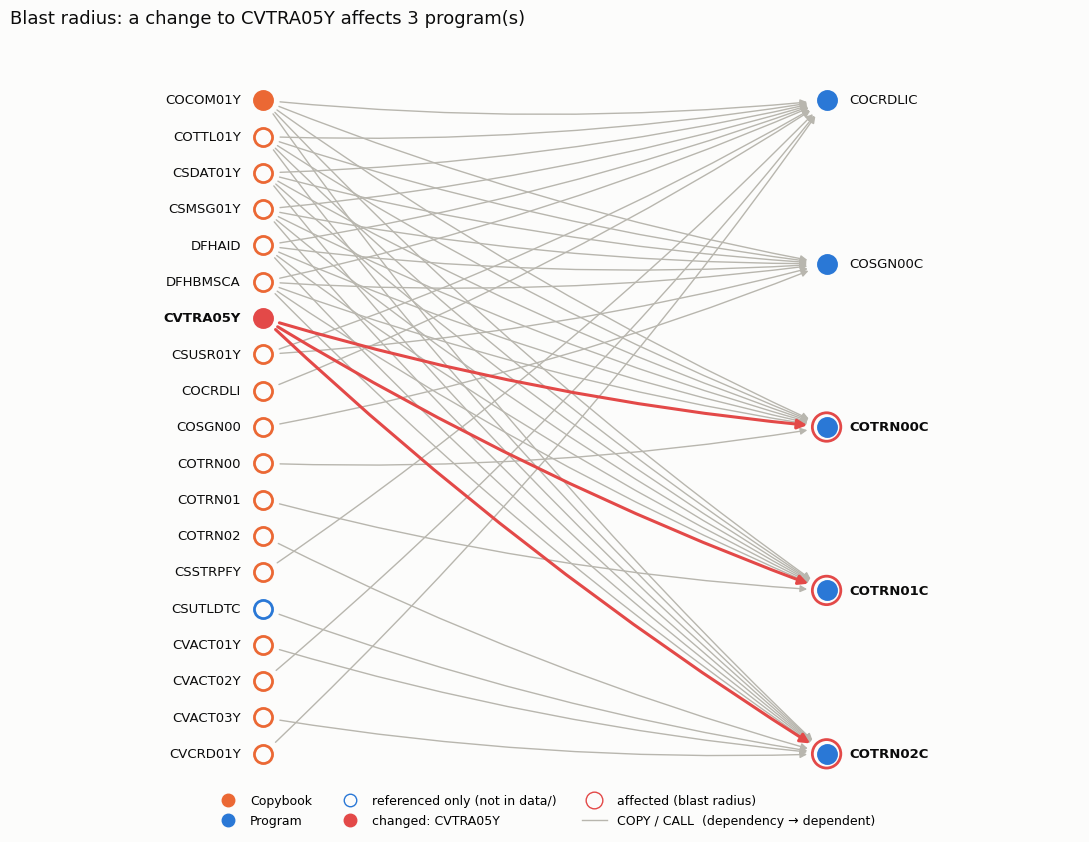

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================ Extract relationships ================================================
COPY_RE = re.compile(r"^\s*COPY\s+'?([A-Z0-9-]+)'?", re.IGNORECASE)
CALL_RE = re.compile(r"\bCALL\s+'([A-Z0-9-]+)'", re.IGNORECASE)

G = nx.DiGraph()
for f in DATA_FILES:
    G.add_node(f.stem, kind="Copybook" if f.suffix.lower() == ".cpy" else "Program", in_data=True)

for f in DATA_FILES:
    for no, line in enumerate(cobol_lines(f.read_text(errors="replace")), start=1):
        if is_comment(line):
            continue
        body = line[7:]
        if m := COPY_RE.match(body):
            dep = m.group(1).upper()
            if dep not in G:
                G.add_node(dep, kind="Copybook", in_data=False)
            G.add_edge(dep, f.stem, rel="COPY", line=no)
        for m in CALL_RE.finditer(body):
            dep = m.group(1).upper()
            if dep not in G:
                G.add_node(dep, kind="Program", in_data=False)
            G.add_edge(dep, f.stem, rel="CALL", line=no)

n_copy = sum(1 for *_, d in G.edges(data=True) if d["rel"] == "COPY")
n_call = sum(1 for *_, d in G.edges(data=True) if d["rel"] == "CALL")
print(f"Knowledge graph: {G.number_of_nodes()} nodes · {n_copy} COPY edges · {n_call} CALL edge{'s' if n_call != 1 else ''}")
print(f"  programs in data/  : {sorted(n for n, d in G.nodes(data=True) if d['kind'] == 'Program' and d['in_data'])}")
print(f"  copybooks in data/ : {sorted(n for n, d in G.nodes(data=True) if d['kind'] == 'Copybook' and d['in_data'])}")
print(f"  referenced only    : {sorted(n for n, d in G.nodes(data=True) if not d['in_data'])}\n")

# ============================ Question: what is affected if CVTRA05Y changes? ======================
CHANGED = "CVTRA05Y"                                  # TRAN-RECORD – the transaction record layout
affected = nx.descendants(G, CHANGED)

def ascii_tree(g: nx.DiGraph, node: str, prefix: str = "", seen: set | None = None) -> list[str]:
    seen = seen if seen is not None else set()
    out = []
    children = sorted(g.successors(node))
    for i, child in enumerate(children):
        last = i == len(children) - 1
        e = g.edges[node, child]
        tag = "" if g.nodes[child]["in_data"] else "  (not in data/)"
        out.append(f"{prefix}{'└── ' if last else '├── '}{child}  [{e['rel']} at line {e['line']} · {g.nodes[child]['kind']}]{tag}")
        if child not in seen:
            seen.add(child)
            out += ascii_tree(g, child, prefix + ("    " if last else "│   "), seen)
    return out

print(f"Blast radius for a change to {CHANGED} ({G.nodes[CHANGED]['kind']}):  {len(affected)} affected program(s)\n")
print(f"{CHANGED}  ({G.nodes[CHANGED]['kind']}, TRAN-RECORD)")
print("\n".join(ascii_tree(G, CHANGED)))

# For comparison: blast radius of every copybook in the data set
rows = []
for cb in sorted((n for n, d in G.nodes(data=True) if d["kind"] == "Copybook"),
                 key=lambda n: -len(nx.descendants(G, n))):
    desc = sorted(nx.descendants(G, cb))
    rows.append(f"| `{cb}` | {'✔' if G.nodes[cb]['in_data'] else '–'} | {len(desc)} | {', '.join(desc)} |")
display(Markdown("\n**Blast radius of all referenced copybooks**\n\n| Copybook | in data/ | affected programs | which |\n|---|:-:|---:|---|\n" + "\n".join(rows)))

# ============================ Plot: two columns (dependencies -> programs) =========================
COLORS = {"Program": "#2a78d6", "Copybook": "#eb6834", "changed": "#e34948", "edge": "#b8b6ae", "text": "#0b0b0b"}
left  = sorted((n for n in G if G.in_degree(n) == 0), key=lambda n: (-len(nx.descendants(G, n)), n))
right = sorted(n for n in G if G.in_degree(n) > 0)
pos = {n: (0, -i) for i, n in enumerate(left)}
pos.update({n: (1, -i * (len(left) - 1) / max(1, len(right) - 1)) for i, n in enumerate(right)})

fig, ax = plt.subplots(figsize=(11, 8.5))
fig.patch.set_facecolor("#fcfcfb"); ax.set_facecolor("#fcfcfb")
hot_edges = [(u, v) for u, v in G.edges if u == CHANGED or (u in affected and v in affected)]
cold_edges = [e for e in G.edges if e not in hot_edges]
nx.draw_networkx_edges(G, pos, edgelist=cold_edges, ax=ax, edge_color=COLORS["edge"], width=1, arrows=True,
                       arrowsize=10, arrowstyle="-|>", connectionstyle="arc3,rad=0.05", min_source_margin=12, min_target_margin=14)
nx.draw_networkx_edges(G, pos, edgelist=hot_edges, ax=ax, edge_color=COLORS["changed"], width=2.2, arrows=True,
                       arrowsize=14, arrowstyle="-|>", connectionstyle="arc3,rad=0.05", min_source_margin=12, min_target_margin=14)
for n, d in G.nodes(data=True):
    fill = COLORS["changed"] if n == CHANGED else COLORS[d["kind"]]
    ax.scatter(*pos[n], s=170, color=fill if d["in_data"] else "#fcfcfb", edgecolors=fill, linewidths=2, zorder=3)
    if n in affected:
        ax.scatter(*pos[n], s=420, facecolors="none", edgecolors=COLORS["changed"], linewidths=2, zorder=2)
    ax.text(pos[n][0] + (-0.04 if pos[n][0] == 0 else 0.04), pos[n][1], n, ha="right" if pos[n][0] == 0 else "left",
            va="center", fontsize=9.5, color=COLORS["text"], fontweight="bold" if n == CHANGED or n in affected else "normal")
ax.set_xlim(-0.45, 1.45); ax.axis("off")
ax.set_title(f"Blast radius: a change to {CHANGED} affects {len(affected)} program(s)", loc="left", fontsize=13, color=COLORS["text"])
ax.legend(handles=[
    Line2D([], [], marker="o", ls="", ms=9, color=COLORS["Copybook"], label="Copybook"),
    Line2D([], [], marker="o", ls="", ms=9, color=COLORS["Program"], label="Program"),
    Line2D([], [], marker="o", ls="", ms=9, markerfacecolor="#fcfcfb", color=COLORS["Program"], label="referenced only (not in data/)"),
    Line2D([], [], marker="o", ls="", ms=9, color=COLORS["changed"], label=f"changed: {CHANGED}"),
    Line2D([], [], marker="o", ls="", ms=12, markerfacecolor="none", color=COLORS["changed"], label="affected (blast radius)"),
    Line2D([], [], color=COLORS["edge"], lw=1, label="COPY / CALL  (dependency → dependent)"),
], loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, fontsize=9)
plt.tight_layout(); plt.show()